In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
'''骨架坐标点数据集载入'''
import torch
import pandas as pd
import numpy as np
df = pd.read_csv("/content/drive/MyDrive/yoga/landmarks/train_landmarks.csv",encoding='gbk')
df.loc[df['体式']=='downdog', '体式编号'] = 0
df.loc[df['体式']=='goddess', '体式编号'] = 1
df.loc[df['体式']=='lowcobra', '体式编号'] = 2
df.loc[df['体式']=='tree', '体式编号'] = 3
df.loc[df['体式']=='warrior2', '体式编号'] = 4
df.drop(["编号", '体式', '标准/不标准'],axis=1, inplace=True)
dataset_train = df.values
'''dataset_train = []
for set in dataset_train1:
  set_train = []
  for i in [0,2,3,5,11,12,13,15,16,17,18,23,24,25,26,27,28,29,30,31,32]:
    set_train.append(set[i*3])
    set_train.append(set[i*3+1])
    set_train.append(set[i*3+2])
  set_train.append(set[99])
  dataset_train.append(set_train)'''
dataset_train = np.array(dataset_train)
X_train = dataset_train[:,:-1].astype(float)
Y_train = dataset_train[:,-1:].astype(int).squeeze(-1)
X_train, Y_train = torch.Tensor(X_train),torch.LongTensor(Y_train) 
#print(X_train, Y_train)
df = pd.read_csv("/content/drive/MyDrive/yoga/landmarks/test_landmarks.csv",encoding='gbk')
df.loc[df['体式']=='downdog', '体式编号'] = 0
df.loc[df['体式']=='goddess', '体式编号'] = 1
df.loc[df['体式']=='lowcobra', '体式编号'] = 2
df.loc[df['体式']=='tree', '体式编号'] = 3
df.loc[df['体式']=='warrior2', '体式编号'] = 4
df.drop(["编号", '体式', '标准/不标准'],axis=1, inplace=True)
#df.drop(['体式', '标准/不标准'],axis=1, inplace=True)
dataset_test = df.values
'''dataset_test = []
for set in dataset_test1:
  set_test = []
  for i in [0,2,3,5,11,12,13,15,16,17,18,23,24,25,26,27,28,29,30,31,32]:
    set_test.append(set[i*3])
    set_test.append(set[i*3+1])
    set_test.append(set[i*3+2])
  set_test.append(set[99])
  dataset_test.append(set_test)'''
dataset_test = np.array(dataset_test)
X_test = dataset_test[:,:-1].astype(float)
Y_test = dataset_test[:,-1:].astype(int).squeeze(-1)
X_test, Y_test = torch.Tensor(X_test),torch.LongTensor(Y_test)
#print(X_test)
trainset =  torch.utils.data.TensorDataset(X_train,Y_train)
testset = torch.utils.data.TensorDataset(X_test,Y_test)
BATCH_SIZE = 64
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=BATCH_SIZE, shuffle=False)

In [5]:
'''MLP网络'''
import torch.nn as nn
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.all = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Dropout(p=0.5),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )
    def forward(self, x):
        out = self.all(x)
        return out
class NeuralNet2(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet2, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 60)
        self.fc3 = nn.Linear(60, 30)
        self.fc4 = nn.Linear(30, num_classes)
        self.dropout = nn.Dropout(p=0.5)
    def forward(self, x):
        out = self.fc1(x)
        out = self.dropout(out)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.dropout(out)
        out = self.relu(out)
        out = self.fc3(out)
        out = self.dropout(out)
        out = self.relu(out)
        out = self.fc4(out)
        return out

In [6]:
'''定义训练和测试函数'''
import torch.optim as optim
from PIL import ImageFile
import matplotlib.pyplot as plt
def train_test(net, epoch_num, num_print):
    # 优化器
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr = 0.0000004, momentum = 0.9)
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    train_loss_list = []
    test_loss_list = []
    for epoch in range(epoch_num):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # 训练数据
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            # 权重参数清零
            optimizer.zero_grad()
            outputs = net(inputs)  # 正向传播
            loss = criterion(outputs, labels)
            loss.backward()  #  反向传播
            optimizer.step()
            running_loss += loss.item()
            if i %num_print == (num_print-1):
                print('[%d, %4d] loss:%.3f'%(epoch + 1, i+1, running_loss / num_print))
                train_loss_list.append(running_loss/num_print)
                running_loss = 0.0
        test_loss = 0.0
        with torch.no_grad():
            for data in testloader:
              images, labels = data
              images, labels = images.to(device), labels.to(device)
              outputs = net(images)
              #_,predicted = torch.max(outputs.data, 1)
              #print(predicted, labels)
              loss = criterion(outputs, labels)
              test_loss += loss.item()
            test_loss /= len(testloader.dataset)
            print('Test set: Average loss: {:.4f}'.format(test_loss))
            test_loss_list.append(test_loss)
    x_train_loss=[]
    x_test_loss=[]
    for i in range(len(train_loss_list)):
        x_train_loss.append(i+1)
    for i in range(len(test_loss_list)):
        x_test_loss.append(i+1)
    plt.plot(x_train_loss,train_loss_list)
    plt.ylabel("train loss")
    plt.show()
    plt.plot(x_test_loss,test_loss_list)
    plt.ylabel("test loss")
    plt.show()
    print('Finished Training')
    torch.save(net, '/content/drive/MyDrive/yoga/models/YogaRegNet_contrast2.pkl')
import pandas as pd
def test(net):
    correct = 0
    total = 0
    total_l = [0,0,0,0,0]
    correct_l = [0,0,0,0,0]
    pred_y = torch.tensor([])
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            _,predicted = torch.max(outputs.data, 1)
            pred_y = torch.cat([pred_y,predicted])
            #print(predicted, labels)
            total += labels.size(0)
            correct += (predicted == labels).sum().item() 
            for i in range(len(labels)):
                for l in range(5):
                    if labels[i] == torch.tensor(l).to(device):
                        total_l[l] += 1
                        correct_l[l] += (predicted[i] == labels[i]).sum().item()
    #print(pred_y)
    print('测试集精度为：%d%%'%(100 * correct / total))
    print('测试集中下犬式图片的预测精度为：%d%%'%(100 * correct_l[0] / total_l[0]))
    print('测试集中女神式图片的预测精度为：%d%%'%(100 * correct_l[1] / total_l[1]))
    print('测试集中低位眼镜蛇式图片的预测精度为：%d%%'%(100 * correct_l[2] / total_l[2]))
    print('测试集中树式图片的预测精度为：%d%%'%(100 * correct_l[3] / total_l[3]))
    print('测试集中战士二式图片的预测精度为：%d%%'%(100 * correct_l[4] / total_l[4]))
    print('混淆矩阵为：')
    print(pd.crosstab(Y_test, pred_y))

流式输出内容被截断，只能显示最后 5000 行内容。
[5751,    4] loss:0.341
[5751,    8] loss:0.381
[5751,   12] loss:0.371
Test set: Average loss: 0.0110
[5752,    4] loss:0.309
[5752,    8] loss:0.347
[5752,   12] loss:0.446
Test set: Average loss: 0.0111
[5753,    4] loss:0.274
[5753,    8] loss:0.333
[5753,   12] loss:0.375
Test set: Average loss: 0.0142
[5754,    4] loss:0.439
[5754,    8] loss:0.336
[5754,   12] loss:0.384
Test set: Average loss: 0.0124
[5755,    4] loss:0.357
[5755,    8] loss:0.384
[5755,   12] loss:0.381
Test set: Average loss: 0.0157
[5756,    4] loss:0.353
[5756,    8] loss:0.344
[5756,   12] loss:0.376
Test set: Average loss: 0.0170
[5757,    4] loss:0.364
[5757,    8] loss:0.371
[5757,   12] loss:0.409
Test set: Average loss: 0.0141
[5758,    4] loss:0.474
[5758,    8] loss:0.439
[5758,   12] loss:0.372
Test set: Average loss: 0.0106
[5759,    4] loss:0.335
[5759,    8] loss:0.363
[5759,   12] loss:0.342
Test set: Average loss: 0.0141
[5760,    4] loss:0.351
[5760,    8] loss:0.43

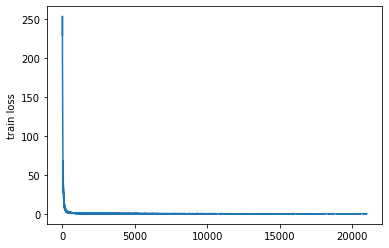

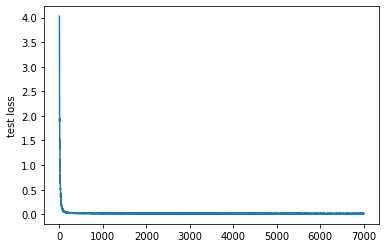

Finished Training


In [7]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
train_test(NeuralNet(input_size=99, hidden_size=69, num_classes=5).to(device),7000,4)

In [19]:
structure = torch.nn.Sequential(*list(model.children())[:])
print(structure)
model = torch.load('/content/drive/MyDrive/yoga/models/YogaRegNet_contrast2.pkl')
print('模型各部分名称', model._modules.keys())

Sequential(
  (0): Sequential(
    (0): Linear(in_features=99, out_features=69, bias=True)
    (1): Dropout(p=0.5, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=69, out_features=5, bias=True)
  )
)
模型各部分名称 odict_keys(['all'])


In [17]:
from torchsummary import summary
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/YogaRegNet_contrast2.pkl')
model.to(device)
summary(model, input_size=(1,99))
print("测试精度如下：")
test(model)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 69]           6,900
           Dropout-2                [-1, 1, 69]               0
              ReLU-3                [-1, 1, 69]               0
            Linear-4                 [-1, 1, 5]             350
Total params: 7,250
Trainable params: 7,250
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.03
Estimated Total Size (MB): 0.03
----------------------------------------------------------------
测试精度如下：
测试集精度为：86%
测试集中下犬式图片的预测精度为：95%
测试集中女神式图片的预测精度为：74%
测试集中低位眼镜蛇式图片的预测精度为：90%
测试集中树式图片的预测精度为：88%
测试集中战士二式图片的预测精度为：78%
混淆矩阵为：
col_0  0.0  1.0  2.0  3.0  4.0
row_0                         
0       69    0    3    0    0
1        1   44    0    4   10
2        5    0   66    0    2
3        0    5   